Extracting EDF parameters from c:\Codes\EEG_Study\codigo_felipe\data\physionet_data\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Frequência de amostragem detectada: 160.0 Hz
Using matplotlib as 2D backend.


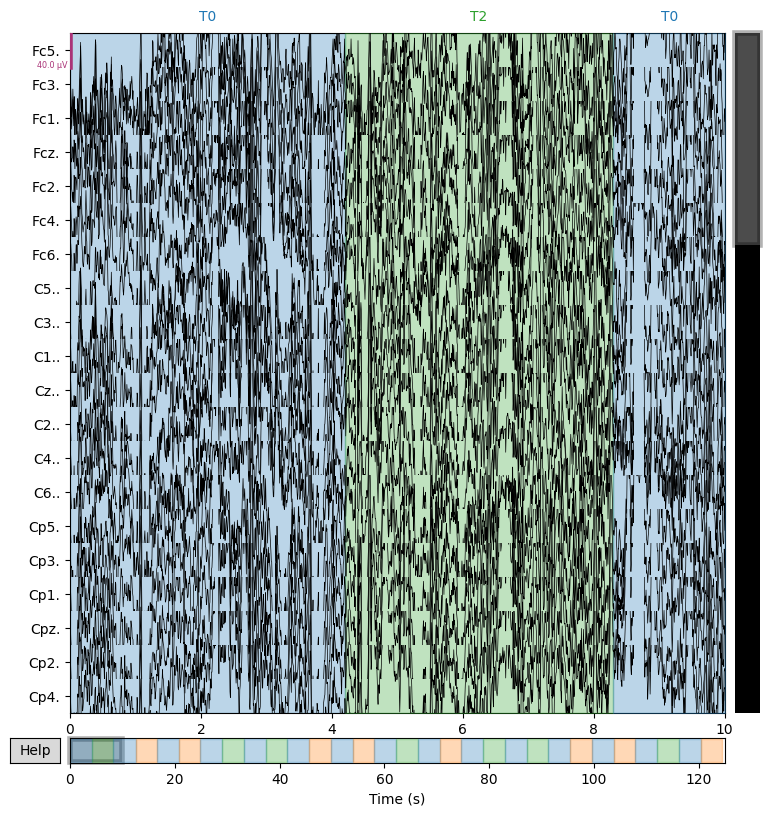

Janela do gráfico fechada. Script finalizado.


In [6]:
import mne

# 1. Coloque o nome do seu arquivo aqui
nome_do_arquivo = 'data\physionet_data\S001\S001R03.edf'

# 2. Carrega o arquivo EDF para a memória
# A biblioteca MNE lê automaticamente a frequência de amostragem e outras informações do arquivo.
raw = mne.io.read_raw_edf(nome_do_arquivo, preload=True)

# (Opcional) Confirma se a frequência de amostragem foi lida corretamente
print(f"Frequência de amostragem detectada: {raw.info['sfreq']} Hz")

# 3. Plota os dados
# Isso abrirá uma janela interativa. Feche a janela para terminar o script.
raw.plot(block=True) 

print("Janela do gráfico fechada. Script finalizado.")

Extracting EDF parameters from c:\Codes\EEG_Study\codigo_felipe\data\physionet_data\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Dados extraídos com sucesso. Shape do array de dados: (3, 19200)
Vetor de tempo extraído com sucesso. Shape: (19200,)


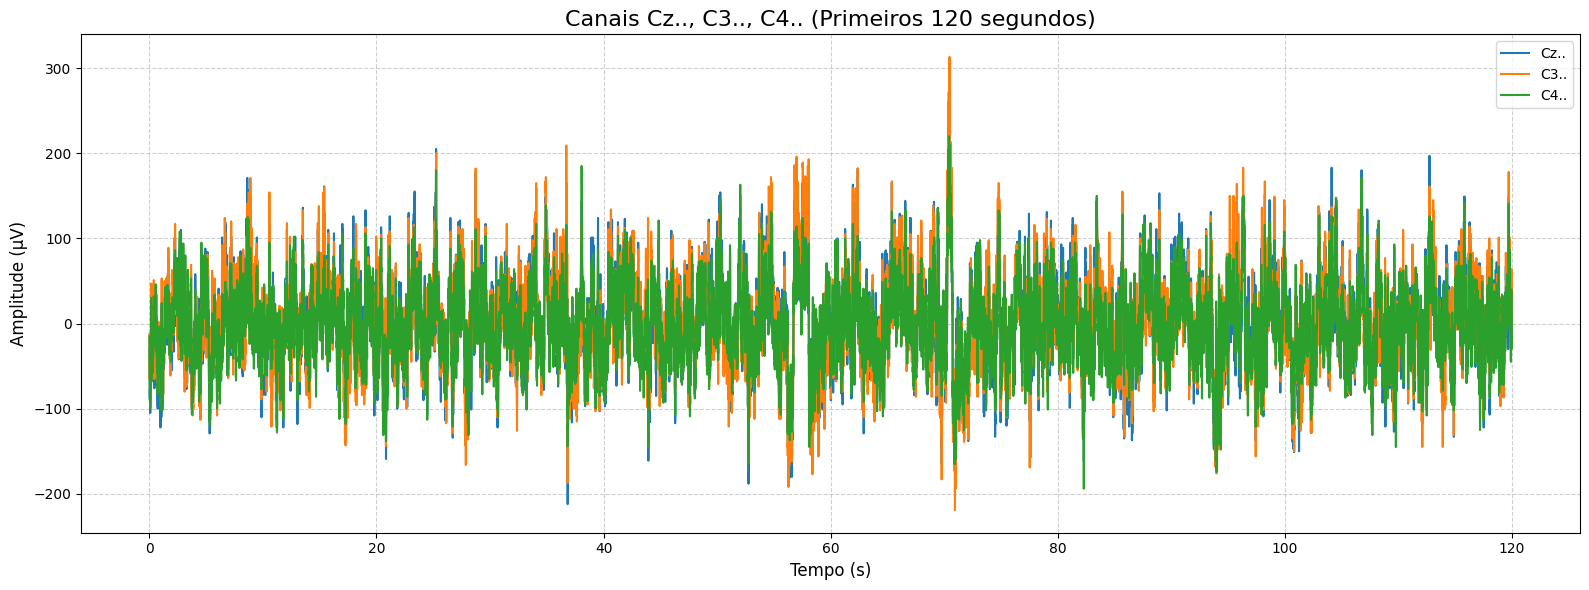

In [16]:
import mne
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configurações Iniciais ---
nome_do_arquivo = r'data\physionet_data\S001\S001R03.edf'
canais_desejados = ['Cz..', 'C3..', 'C4..']
cores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Cores padrão do Matplotlib (azul, laranja, verde)

# Tempo desejado em segundos
inicio_s = 0
duracao_s = 120
fim_s = inicio_s + duracao_s

try:
    # --- 2. Carregar os dados com MNE ---
    raw = mne.io.read_raw_edf(nome_do_arquivo, preload=True)

    # --- 3. Extrair os dados para o Matplotlib ---
    
    # Converte o tempo em segundos para amostras (índices do array)
    inicio_amostra, fim_amostra = raw.time_as_index([inicio_s, fim_s])

    # Pega os dados dos canais e o vetor de tempo correspondente
    # O MNE retorna os dados em Volts (V), por isso vamos converter para microvolts (µV)
    dados, tempos = raw.get_data(
        picks=canais_desejados, 
        start=inicio_amostra, 
        stop=fim_amostra, 
        return_times=True
    )
    
    # Converte de Volts para microvolts (multiplica por 1 milhão)
    dados_uV = dados * 1e6
    
    print(f"Dados extraídos com sucesso. Shape do array de dados: {dados_uV.shape}")
    print(f"Vetor de tempo extraído com sucesso. Shape: {tempos.shape}")


    # --- 4. Plotar com Matplotlib ---
    
    # Cria a figura e os eixos (o "canvas" do nosso gráfico)
    fig, ax = plt.subplots(figsize=(16, 6)) # Define um bom tamanho para visualização de séries temporais

    # Itera sobre cada canal (cada linha do nosso array de 'dados')
    for i, nome_canal in enumerate(canais_desejados):
        ax.plot(
            tempos,         # Eixo X: nosso vetor de tempo
            dados_uV[i],    # Eixo Y: os dados do canal atual
            label=nome_canal, # Rótulo para a legenda
            color=cores[i]    # Cor específica para este canal
        )

    # --- 5. Personalizar o Gráfico ---
    ax.set_title(f'Canais {", ".join(canais_desejados)} (Primeiros {duracao_s} segundos)', fontsize=16)
    ax.set_xlabel('Tempo (s)', fontsize=12)
    ax.set_ylabel('Amplitude (µV)', fontsize=12)
    ax.legend(loc='upper right') # Adiciona a legenda ao gráfico
    ax.grid(True, linestyle='--', alpha=0.6) # Adiciona um grid para facilitar a leitura
    
    # Ajusta o layout para garantir que nada seja cortado
    plt.tight_layout()

    # Mostra o gráfico final
    plt.show()


except FileNotFoundError:
    print(f"ERRO: O arquivo '{nome_do_arquivo}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

def create_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Reshape((input_shape[0], input_shape[1], 1)),
        
        # Camadas convolucionais
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Camadas temporais
        layers.Reshape((-1, 64)),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        
        # Classificação
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Pré-processamento de exemplo
def process_signal(eeg_signal, window_size, step_size, fs=160):
    windows = []
    for start in range(0, len(eeg_signal) - window_size, step_size):
        window = eeg_signal[start:start+window_size]
        stft = np.abs(tf.signal.stft(
            window,
            frame_length=64,
            frame_step=16,
            fft_length=128
        ))
        windows.append(stft)
    return np.array(windows)

# Uso:
# X_train = np.array([process_signal(sig, 400, 100) for sig in raw_signals])
# model = create_model(X_train[0].shape, num_classes=4)

Aplicando filtro passa-faixa de 8-30 Hz...
Filtro aplicado com sucesso.

Formato do array de saída após filtragem e processamento: (59, 38, 65)


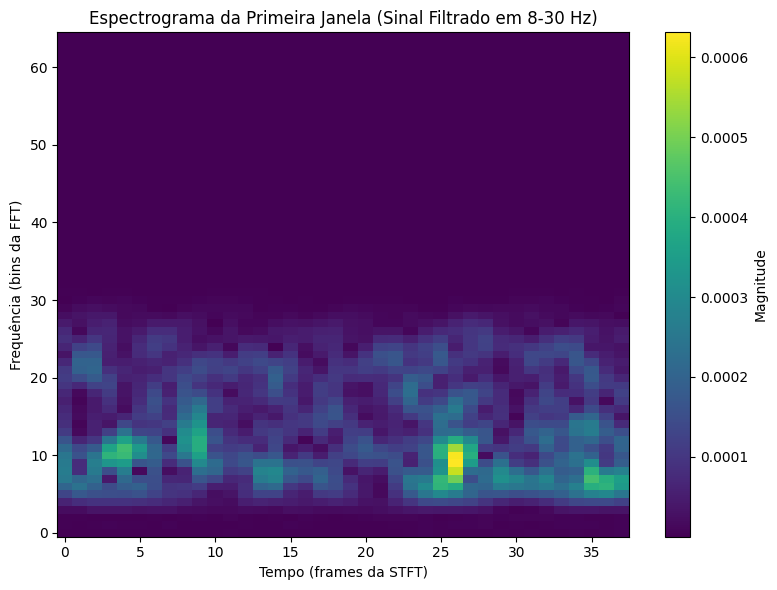

In [18]:
import mne
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# 1. SUA FUNÇÃO DE PRÉ-PROCESSAMENTO (sem alterações)
# --------------------------------------------------------------------
def process_signal(eeg_signal, window_size, step_size, fs=160):
    windows = []
    for start in range(0, len(eeg_signal) - window_size, step_size):
        window = eeg_signal[start:start+window_size]
        stft = np.abs(tf.signal.stft(
            window, frame_length=64, frame_step=16, fft_length=128
        ))
        windows.append(stft)
    return np.array(windows)

# --------------------------------------------------------------------
# 2. CARREGANDO E FILTRANDO OS DADOS
# --------------------------------------------------------------------
# Carrega o arquivo EDF
nome_do_arquivo = r'data\physionet_data\S001\S001R03.edf'
raw = mne.io.read_raw_edf(nome_do_arquivo, preload=True, verbose=False)

# ---->>> MODIFICAÇÃO PRINCIPAL AQUI <<<----
# Aplica o filtro passa-faixa de 8 Hz a 30 Hz.
print("Aplicando filtro passa-faixa de 8-30 Hz...")
raw.filter(l_freq=8, h_freq=30, verbose=False)
print("Filtro aplicado com sucesso.")

# Extrai os dados JÁ FILTRADOS de um único canal (ex: Cz)
eeg_cz_filtrado = raw.get_data(picks=['Cz..'])[0] 

# --------------------------------------------------------------------
# 3. DEFININDO OS PARÂMETROS E EXECUTANDO A FUNÇÃO
# --------------------------------------------------------------------
fs = int(raw.info['sfreq'])
tamanho_janela_s = 4.1
window_size = int(tamanho_janela_s * fs)
step_size = window_size // 2  # Usando metade do tamanho da janela como passo

processed_data = process_signal(eeg_cz_filtrado, window_size, step_size, fs=fs)

# --------------------------------------------------------------------
# 4. INSPECIONANDO O RESULTADO
# --------------------------------------------------------------------
print(f"\nFormato do array de saída após filtragem e processamento: {processed_data.shape}")

# --------------------------------------------------------------------
# 5. VISUALIZANDO UM DOS ESPECTROGRAMAS GERADOS
# --------------------------------------------------------------------
if processed_data.shape[0] > 0:
    plt.figure(figsize=(8, 6))
    plt.imshow(processed_data[0].T, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.title('Espectrograma da Primeira Janela (Sinal Filtrado em 8-30 Hz)')
    plt.xlabel('Tempo (frames da STFT)')
    plt.ylabel('Frequência (bins da FFT)')
    plt.tight_layout()
    plt.show()

In [ ]:
import mne
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time

# --------------------------------------------------------------------
# 1. FUNÇÃO DE PRÉ-PROCESSAMENTO
# --------------------------------------------------------------------
def process_signal(eeg_signal, window_size, step_size, fs=160):
    windows = []
    for start in range(0, len(eeg_signal) - window_size, step_size):
        window = eeg_signal[start:start+window_size]
        stft = np.abs(tf.signal.stft(
            window, frame_length=64, frame_step=16, fft_length=128
        ))
        windows.append(stft)
    return np.array(windows)

# --------------------------------------------------------------------
# 2. FUNÇÃO AUXILIAR PARA DETERMINAR A CLASSE PELO TEMPO
# --------------------------------------------------------------------
def get_class_from_time(time_s, annotations):
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time = ann['onset']
            end_time = start_time + ann['duration']
            if start_time <= time_s < end_time:
                return ann['description']
    return 'T0'

# ====================================================================
# INÍCIO DO SCRIPT PRINCIPAL
# ====================================================================
start_time_total = time.time()

# --- Definições Iniciais ---
nome_do_arquivo = r'data\physionet_data\S001\S001R03.edf'
canais_desejados = ['Cz..', 'C3..', 'C4..']
pasta_principal = 'espectrogramas_multicanal'

# --- Carregamento e Filtragem (feitos uma única vez) ---
raw = mne.io.read_raw_edf(nome_do_arquivo, preload=True, verbose=False)
raw.filter(l_freq=8, h_freq=30, verbose=False)
print(f"Arquivo '{nome_do_arquivo}' carregado e filtrado (8-30 Hz).")

fs = int(raw.info['sfreq'])
tamanho_janela_s = 4
window_size = int(tamanho_janela_s * fs)
step_size = window_size // 2

# --- Loop Principal por Canal ---
for nome_canal in canais_desejados:
    print(f"\n{'='*50}")
    print(f"PROCESSANDO CANAL: {nome_canal}")
    print(f"{'='*50}")

    # --- Extração de dados para o canal atual ---
    eeg_filtrado_canal = raw.get_data(picks=[nome_canal])[0]
    
    # --- Geração dos espectrogramas para o canal atual ---
    print(f"Gerando espectrogramas para o canal {nome_canal}...")
    processed_data = process_signal(eeg_filtrado_canal, window_size, step_size, fs=fs)
    print(f"Processamento concluído. {processed_data.shape[0]} espectrogramas gerados.")

    # --- Salvando os espectrogramas com as classes ---
    pasta_canal = os.path.join(pasta_principal, nome_canal.replace('.', '')) # Cria pasta ex: 'Cz'
    print(f"Salvando imagens em: '{pasta_canal}/'")

    for i, spec in enumerate(processed_data):
        # Calcula o tempo de início desta janela
        start_sample = i * step_size
        start_time_s = start_sample / fs
        
        # Obtém a classe para o tempo de início
        classe = get_class_from_time(start_time_s, raw.annotations)
        
        # Cria a subpasta da classe dentro da pasta do canal
        pasta_classe = os.path.join(pasta_canal, classe)
        os.makedirs(pasta_classe, exist_ok=True)
        
        # Define o nome do arquivo
        nome_arquivo = f'{classe}_espectrograma_{i:04d}.png'
        caminho_completo = os.path.join(pasta_classe, nome_arquivo)
        
        # Plota e salva a imagem
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(spec.T, aspect='auto', origin='lower', cmap='viridis')
        fig.colorbar(im, ax=ax, label='Magnitude')
        ax.set_title(f'Canal {nome_canal} - Spec #{i+1} (Classe: {classe})')
        ax.set_xlabel('Tempo (frames)')
        ax.set_ylabel('Frequência (bins)')
        plt.savefig(caminho_completo)
        plt.close(fig)

end_time_total = time.time()
print(f"\n\n{'*' * 50}")
print("TODOS OS CANAIS FORAM PROCESSADOS COM SUCESSO!")
print(f"Tempo total de execução: {end_time_total - start_time_total:.2f} segundos.")
print(f"Verifique a pasta '{pasta_principal}' para ver os resultados.")
print(f"{'*' * 50}")

Arquivo 'data\physionet_data\S001\S001R03.edf' carregado e filtrado (8-30 Hz).

PROCESSANDO CANAL: Cz..
Gerando espectrogramas para o canal Cz.....
Processamento concluído. 59 espectrogramas gerados.
Salvando imagens em: 'espectrogramas_multicanal\Cz/'

PROCESSANDO CANAL: C3..
Gerando espectrogramas para o canal C3.....
Processamento concluído. 59 espectrogramas gerados.
Salvando imagens em: 'espectrogramas_multicanal\C3/'

PROCESSANDO CANAL: C4..
Gerando espectrogramas para o canal C4.....
Processamento concluído. 59 espectrogramas gerados.
Salvando imagens em: 'espectrogramas_multicanal\C4/'


**************************************************
TODOS OS CANAIS FORAM PROCESSADOS COM SUCESSO!
Tempo total de execução: 19.90 segundos.
Verifique a pasta 'espectrogramas_multicanal' para ver os resultados.
**************************************************


In [4]:
import mne
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time

#ação a cada 4s -> 640 frames
#frame_length = 64 -> é a janela pequena que vai andando pelo sinal
#frame_step = 16 -> vai definir o overlap (pular 16 frames depois de cada janela = 75% overlap)
#fft_length = 64 -> aumenta a resolução do spectrograma
def process_signal(eeg_signal, window_size, step_size, fs=160, fft_length=256):
    windows = []
    for start in range(0, len(eeg_signal) - window_size, step_size):
        window = eeg_signal[start:start+window_size]
        stft = np.abs(tf.signal.stft(
            window, frame_length=64, frame_step=16, fft_length=fft_length
        ))
        windows.append(stft)
    return np.array(windows)

def get_class_from_time(time_s, annotations):
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time = ann['onset']
            end_time = start_time + ann['duration']
            if start_time <= time_s < end_time:
                return ann['description']
    return 'T0'

# ====================================================================
# INÍCIO DO SCRIPT PRINCIPAL
# ====================================================================
start_time_total = time.time()

# --- Definições Iniciais ---
nome_do_arquivo = r'data\physionet_data\S001\S001R03.edf'
canais_desejados = ['Cz..', 'C3..', 'C4..']
pasta_principal = 'espectrogramas_multicanal_fft64_75Overlap_400ms'
l_freq, h_freq = 8, 30
fft_length = 128

# --- Carregamento e Filtragem ---
raw = mne.io.read_raw_edf(nome_do_arquivo, preload=True, verbose=False)
raw.filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
print(f"Arquivo '{nome_do_arquivo}' carregado e filtrado ({l_freq}-{h_freq} Hz).")

fs = int(raw.info['sfreq'])
tamanho_janela_s = 4.1
window_size = int(tamanho_janela_s * fs)
step_size = window_size // 4

# --- CÁLCULO DOS ÍNDICES DE FREQUÊNCIA (FEITO UMA VEZ) ---
# Calcula o vetor de frequências que corresponde às linhas do espectrograma
freqs = np.fft.rfftfreq(n=fft_length, d=1/fs)
# Encontra os índices das linhas que estão dentro da nossa faixa de interesse (8-30 Hz)
freq_indices = np.where((freqs >= l_freq) & (freqs <= h_freq))[0]
# Frequências correspondentes para usar nos eixos do gráfico depois
freqs_recortadas = freqs[freq_indices]
print(f"Espectrogramas serão recortados para a faixa de frequência de {freqs_recortadas.min():.1f} a {freqs_recortadas.max():.1f} Hz.")


# --- Loop Principal por Canal ---
for nome_canal in canais_desejados:
    print(f"\n{'='*50}\nPROCESSANDO CANAL: {nome_canal}\n{'='*50}")

    eeg_filtrado_canal = raw.get_data(picks=[nome_canal])[0]
    
    print(f"Gerando espectrogramas para o canal {nome_canal}...")
    processed_data = process_signal(eeg_filtrado_canal, window_size, step_size, fs=fs, fft_length=fft_length)
    
    # --- RECORTA TODOS OS ESPECTROGRAMAS DE UMA VEZ ---
    processed_data_recortado = processed_data[:, freq_indices, :]
    print(f"Espectrogramas recortados. Novo shape: {processed_data_recortado.shape}")

    pasta_canal = os.path.join(pasta_principal, nome_canal.replace('.', ''))
    print(f"Salvando imagens em: '{pasta_canal}/'")

    for i, spec_recortado in enumerate(processed_data_recortado):
        start_sample = i * step_size
        start_time_s = start_sample / fs
        classe = get_class_from_time(start_time_s, raw.annotations)
        
        pasta_classe = os.path.join(pasta_canal, classe)
        os.makedirs(pasta_classe, exist_ok=True)
        
        nome_arquivo = f'{classe}_espectrograma_{i:04d}.png'
        caminho_completo = os.path.join(pasta_classe, nome_arquivo)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        # Agora plotamos o espectrograma já recortado
        im = ax.imshow(spec_recortado, aspect='auto', origin='lower', cmap='viridis', 
                       extent=[0, spec_recortado.shape[1], freqs_recortadas.min(), freqs_recortadas.max()])
        
        fig.colorbar(im, ax=ax, label='Magnitude')
        ax.set_title(f'Canal {nome_canal} - Spec #{i+1} (Classe: {classe})')
        ax.set_xlabel('Tempo (frames)')
        ax.set_ylabel('Frequência (Hz)') # O eixo Y agora está em Hz
        
        plt.savefig(caminho_completo)
        plt.close(fig)

end_time_total = time.time()
print(f"\n\n{'*' * 50}\nTODOS OS CANAIS FORAM PROCESSADOS COM SUCESSO!\n{'*' * 50}")
print(f"Tempo total de execução: {end_time_total - start_time_total:.2f} segundos.")
print(f"Verifique a pasta '{pasta_principal}' para ver os resultados.")

Arquivo 'data\physionet_data\S001\S001R03.edf' carregado e filtrado (8-30 Hz).
Espectrogramas serão recortados para a faixa de frequência de 8.8 a 30.0 Hz.

PROCESSANDO CANAL: Cz..
Gerando espectrogramas para o canal Cz.....
Espectrogramas recortados. Novo shape: (118, 18, 65)
Salvando imagens em: 'espectrogramas_multicanal_fft64_75Overlap_400ms\Cz/'

PROCESSANDO CANAL: C3..
Gerando espectrogramas para o canal C3.....
Espectrogramas recortados. Novo shape: (118, 18, 65)
Salvando imagens em: 'espectrogramas_multicanal_fft64_75Overlap_400ms\C3/'

PROCESSANDO CANAL: C4..
Gerando espectrogramas para o canal C4.....
Espectrogramas recortados. Novo shape: (118, 18, 65)
Salvando imagens em: 'espectrogramas_multicanal_fft64_75Overlap_400ms\C4/'


**************************************************
TODOS OS CANAIS FORAM PROCESSADOS COM SUCESSO!
**************************************************
Tempo total de execução: 40.67 segundos.
Verifique a pasta 'espectrogramas_multicanal_fft64_75Overlap_

Iniciando coleta e pré-processamento de dados...
Espectrogramas serão recortados para 18 bins de frequência.
Processando arquivo: data/physionet_data/S001\S001R03.edf
Processando arquivo: data/physionet_data/S001\S001R07.edf
Processando arquivo: data/physionet_data/S001\S001R11.edf
Processando arquivo: data/physionet_data/S002\S002R03.edf
Processando arquivo: data/physionet_data/S002\S002R07.edf
Processando arquivo: data/physionet_data/S002\S002R11.edf
Processando arquivo: data/physionet_data/S003\S003R03.edf
Processando arquivo: data/physionet_data/S003\S003R07.edf
Processando arquivo: data/physionet_data/S003\S003R11.edf
Processando arquivo: data/physionet_data/S004\S004R03.edf
Processando arquivo: data/physionet_data/S004\S004R07.edf
Processando arquivo: data/physionet_data/S004\S004R11.edf
Processando arquivo: data/physionet_data/S005\S005R03.edf
Processando arquivo: data/physionet_data/S005\S005R07.edf
Processando arquivo: data/physionet_data/S005\S005R11.edf
Processando arquivo: 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 65, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 32, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 32, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 32, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 16, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,747 (530.26 KB)

 Trainable params: 135,555 (529.51 KB)

 Non-trainable params: 192 (768.00 B)


Iniciando o treinamento do modelo...
Epoch 1/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.5204 - loss: 1.0332 - val_accuracy: 0.2510 - val_loss: 1.0922
Epoch 2/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.5328 - loss: 1.0091 - val_accuracy: 0.5275 - val_loss: 1.0230
Epoch 3/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.5308 - loss: 1.0029 - val_accuracy: 0.5275 - val_loss: 2.9337
Epoch 4/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.5256 - loss: 0.9988 - val_accuracy: 0.5275 - val_loss: 1.4609
Epoch 5/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.5231 - loss: 0.9875 - val_accuracy: 0.5275 - val_loss: 2.6164
Epoch 6/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.5303 - loss: 0.9773 - val_accuracy: 0.5261 - val_loss: 1.0682
Epoch 7/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.5270 - loss: 0.9749 - val_accuracy: 0.5275 - val_loss: 1.0246

Treinamento finalizado. Avaliando o modelo no conju

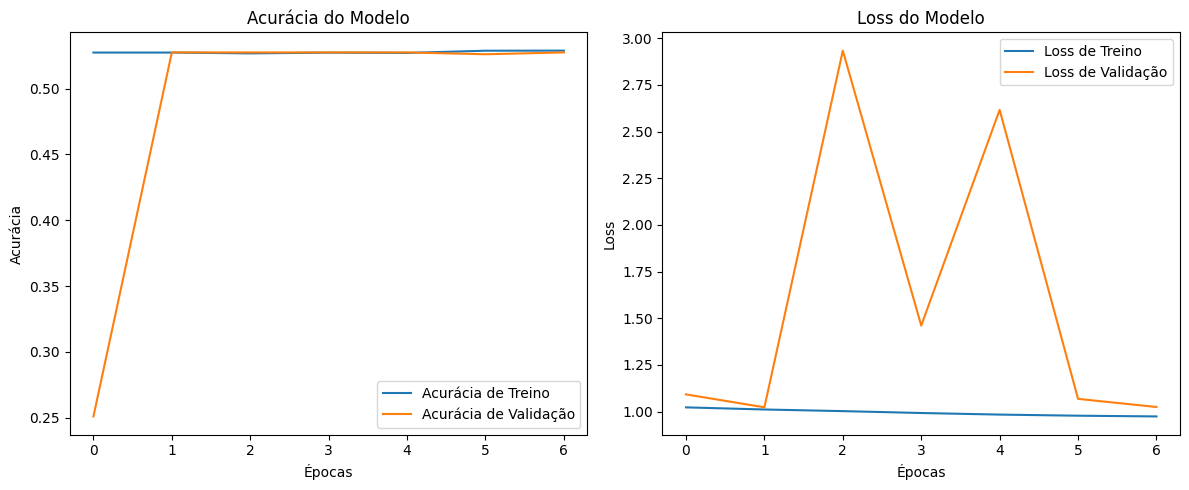

In [ ]:
import os
import time
import mne
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS
# ====================================================================
DATA_PATH = 'data/physionet_data/'
TARGET_RUNS = ['03', '07', '11']
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..'] # Ordem é importante

L_FREQ, H_FREQ = 8, 30
FS = 160
JANELA_S = 4.0
WINDOW_SIZE = int(JANELA_S * FS)
STEP_SIZE = WINDOW_SIZE // 4 # Aumentando o overlap para 75% para gerar mais dados

FRAME_LENGTH = 64
FRAME_STEP = 16
FFT_LENGTH = 128

NUM_SUBJECTS = 50
TEST_SIZE = 0.2
EPOCHS = 20 # Aumentando um pouco as épocas
BATCH_SIZE = 16 # Aumentando o batch size

# ====================================================================
# 2. FUNÇÕES AUXILIARES
# ====================================================================
def create_model(input_shape, num_classes):
    """Cria o modelo CRNN para entrada multicanal."""
    model = models.Sequential([
        # A entrada já terá o formato (altura, largura, canais), ex: (25, 41, 3)
        layers.Input(shape=input_shape),
        
        # A camada Reshape para adicionar o canal '1' foi REMOVIDA.
        # A Conv2D agora opera diretamente nos 3 canais de entrada.
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),

        # O restante do modelo permanece o mesmo
        layers.Reshape((-1, 64)),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def process_multichannel_signal(eeg_data_multichannel, window_size, step_size, fs=FS, fft_length=FFT_LENGTH):
    """
    Gera tensores de espectrograma (freq, tempo, canal) a partir de dados multicanal.
    """
    num_channels = eeg_data_multichannel.shape[0]
    processed_windows = []

    for start in range(0, eeg_data_multichannel.shape[1] - window_size, step_size):
        # Pega a janela de tempo de todos os canais
        window_multichannel = eeg_data_multichannel[:, start:start + window_size]
        
        channel_spectrograms = []
        for i in range(num_channels):
            # Calcula o STFT para cada canal individualmente
            stft = np.abs(tf.signal.stft(
                window_multichannel[i],
                frame_length=FRAME_LENGTH,
                frame_step=FRAME_STEP,
                fft_length=fft_length
            ))
            channel_spectrograms.append(stft)
        
        # Empilha os espectrogramas no último eixo para criar o tensor (freq, tempo, canais)
        stacked_spectrogram = np.stack(channel_spectrograms, axis=-1)
        processed_windows.append(stacked_spectrogram)
        
    return np.array(processed_windows)


def get_class_from_time(time_s, annotations):
    """Determina a classe (T0, T1, T2) com base no tempo e anotações."""
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time = ann['onset']
            end_time = start_time + ann['duration']
            if start_time <= time_s < end_time:
                return ann['description']
    return 'T0'

# ====================================================================
# 3. COLETA E PRÉ-PROCESSAMENTO DOS DADOS
# ====================================================================
print("Iniciando coleta e pré-processamento de dados...")
all_spectrograms = []
all_labels = []

# --- Cálculo dos Índices de Frequência para Recorte ---
freqs = np.fft.rfftfreq(n=FFT_LENGTH, d=1/FS)
freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]
print(f"Espectrogramas serão recortados para {len(freq_indices)} bins de frequência.")

# --- Loop principal para varrer todos os sujeitos e arquivos ---
files_processed = 0
for subject_num in range(1, NUM_SUBJECTS + 1):
    subject_id = f'S{subject_num:03d}'
    subject_path = os.path.join(DATA_PATH, subject_id)

    if not os.path.isdir(subject_path):
        continue

    for run_num in TARGET_RUNS:
        file_name = f'{subject_id}R{run_num}.edf'
        file_path = os.path.join(subject_path, file_name)

        if os.path.exists(file_path):
            try:
                print(f"Processando arquivo: {file_path}")
                files_processed += 1
                
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

                # Extrai os 3 canais de uma só vez
                eeg_data_multichannel = raw.get_data(picks=TARGET_CHANNELS)

                # Processa os 3 canais juntos
                spectrograms = process_multichannel_signal(eeg_data_multichannel, WINDOW_SIZE, STEP_SIZE)
                
                if spectrograms.shape[0] > 0:
                    # Recorta na dimensão da frequência
                    spectrograms_cropped = spectrograms[:, freq_indices, :, :]
                    
                    for i, spec in enumerate(spectrograms_cropped):
                        start_time_s = (i * STEP_SIZE) / FS
                        label = get_class_from_time(start_time_s, raw.annotations)
                        
                        all_spectrograms.append(spec)
                        all_labels.append(label)
            except Exception as e:
                print(f"Erro ao processar {file_path}: {e}")

# ====================================================================
# 4. PREPARAÇÃO FINAL E DIVISÃO DO DATASET
# ====================================================================
X = np.array(all_spectrograms)
y_str = np.array(all_labels)

encoder = LabelEncoder()
y = encoder.fit_transform(y_str)
print(f"\nClasses encontradas e codificadas: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)
print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")

# ====================================================================
# 5. CRIAÇÃO, TREINAMENTO E AVALIAÇÃO DO MODELO
# ====================================================================
if len(X_train) > 0:
    input_shape = X_train.shape[1:]
    num_classes = len(encoder.classes_)

    model = create_model(input_shape, num_classes)
    model.summary()

    print("\nIniciando o treinamento do modelo...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    print("\nTreinamento finalizado. Avaliando o modelo no conjunto de teste...")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nAcurácia no conjunto de teste: {accuracy*100:.2f}%")
    print(f"Loss no conjunto de teste: {loss:.4f}")

    # --- Plotar histórico de treinamento ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Acurácia de Treino')
    plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
    plt.title('Acurácia do Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss de Treino')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.title('Loss do Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado foi gerado. Verifique os caminhos e parâmetros.")

Iniciando coleta e pré-processamento de dados...
Processando arquivo: data/physionet_data/S001\S001R03.edf
Processando arquivo: data/physionet_data/S001\S001R07.edf
Processando arquivo: data/physionet_data/S001\S001R11.edf
Processando arquivo: data/physionet_data/S002\S002R03.edf
Processando arquivo: data/physionet_data/S002\S002R07.edf
Processando arquivo: data/physionet_data/S002\S002R11.edf
Processando arquivo: data/physionet_data/S003\S003R03.edf
Processando arquivo: data/physionet_data/S003\S003R07.edf
Processando arquivo: data/physionet_data/S003\S003R11.edf
Processando arquivo: data/physionet_data/S004\S004R03.edf
Processando arquivo: data/physionet_data/S004\S004R07.edf
Processando arquivo: data/physionet_data/S004\S004R11.edf
Processando arquivo: data/physionet_data/S005\S005R03.edf
Processando arquivo: data/physionet_data/S005\S005R07.edf
Processando arquivo: data/physionet_data/S005\S005R11.edf
Processando arquivo: data/physionet_data/S006\S006R03.edf
Processando arquivo: da

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 18, 65, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 32, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 32, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 32, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 16, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,747 (530.26 KB)

 Trainable params: 135,555 (529.51 KB)

 Non-trainable params: 192 (768.00 B)


Iniciando o treinamento do modelo com dados balanceados...
Epoch 1/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3351 - loss: 1.1003 - val_accuracy: 0.3333 - val_loss: 1.1002
Epoch 2/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3247 - loss: 1.0998 - val_accuracy: 0.3333 - val_loss: 1.1308
Epoch 3/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.3429 - loss: 1.0971 - val_accuracy: 0.3333 - val_loss: 1.1153
Epoch 4/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3773 - loss: 1.0926 - val_accuracy: 0.3345 - val_loss: 1.1356
Epoch 5/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.3811 - loss: 1.0868 - val_accuracy: 0.3329 - val_loss: 1.1099
Epoch 6/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.3991 - loss: 1.0807 - val_accuracy: 0.3337 - val_loss: 1.1329

Treinamento finalizado. Avaliando o modelo no conjunto de teste...

Acurácia no conjunto de teste: 33.33%
Loss no conjunto de teste: 1.1002


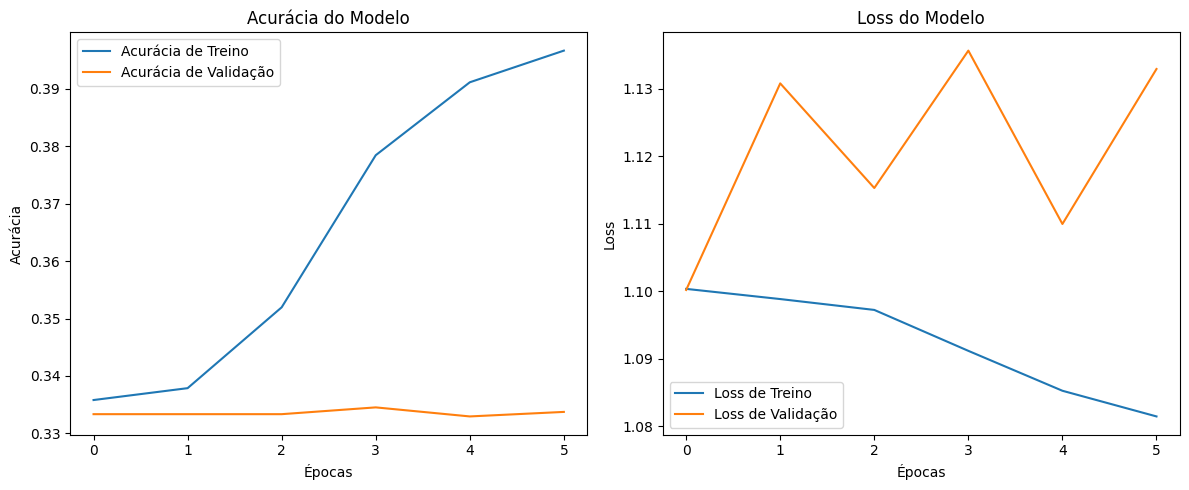

In [3]:
import os
import time
import mne
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import random

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS (sem alterações)
# ====================================================================
DATA_PATH = 'data/physionet_data/'
TARGET_RUNS = ['03', '07', '11']
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..']
L_FREQ, H_FREQ = 8, 30
FS = 160
JANELA_S = 4.0
WINDOW_SIZE = int(JANELA_S * FS)
STEP_SIZE = WINDOW_SIZE // 4
FFT_LENGTH = 128
NUM_SUBJECTS = 50
TEST_SIZE = 0.2
EPOCHS = 20
BATCH_SIZE = 16

# ====================================================================
# 2. FUNÇÕES AUXILIARES (sem alterações)
# ====================================================================
def create_model(input_shape, num_classes):
    # ... (código da função create_model sem alterações)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Reshape((-1, 64)),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def process_multichannel_signal(eeg_data_multichannel, window_size, step_size, fs=FS, fft_length=FFT_LENGTH):
    # ... (código da função process_multichannel_signal sem alterações)
    num_channels = eeg_data_multichannel.shape[0]
    processed_windows = []
    for start in range(0, eeg_data_multichannel.shape[1] - window_size, step_size):
        window_multichannel = eeg_data_multichannel[:, start:start + window_size]
        channel_spectrograms = []
        for i in range(num_channels):
            stft = np.abs(tf.signal.stft(window_multichannel[i], frame_length=FRAME_LENGTH, frame_step=FRAME_STEP, fft_length=fft_length))
            channel_spectrograms.append(stft)
        stacked_spectrogram = np.stack(channel_spectrograms, axis=-1)
        processed_windows.append(stacked_spectrogram)
    return np.array(processed_windows)

def get_class_from_time(time_s, annotations):
    # ... (código da função get_class_from_time sem alterações)
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time = ann['onset']
            end_time = start_time + ann['duration']
            if start_time <= time_s < end_time:
                return ann['description']
    return 'T0'

# ====================================================================
# 3. COLETA E PRÉ-PROCESSAMENTO DOS DADOS (sem alterações)
# ====================================================================
print("Iniciando coleta e pré-processamento de dados...")
all_spectrograms = []
all_labels = []
freqs = np.fft.rfftfreq(n=FFT_LENGTH, d=1/FS)
freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]
files_processed = 0
for subject_num in range(1, NUM_SUBJECTS + 1):
    subject_id = f'S{subject_num:03d}'
    # ... (resto do loop de coleta de dados sem alterações)
    subject_path = os.path.join(DATA_PATH, subject_id)
    if not os.path.isdir(subject_path): continue
    for run_num in TARGET_RUNS:
        file_path = os.path.join(subject_path, f'{subject_id}R{run_num}.edf')
        if os.path.exists(file_path):
            try:
                print(f"Processando arquivo: {file_path}")
                files_processed += 1
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)
                eeg_data_multichannel = raw.get_data(picks=TARGET_CHANNELS)
                spectrograms = process_multichannel_signal(eeg_data_multichannel, WINDOW_SIZE, STEP_SIZE)
                if spectrograms.shape[0] > 0:
                    spectrograms_cropped = spectrograms[:, freq_indices, :, :]
                    for i, spec in enumerate(spectrograms_cropped):
                        start_time_s = (i * STEP_SIZE) / FS
                        label = get_class_from_time(start_time_s, raw.annotations)
                        all_spectrograms.append(spec)
                        all_labels.append(label)
            except Exception as e:
                print(f"Erro ao processar {file_path}: {e}")

print(f"\nColeta de dados finalizada. {files_processed} arquivos processados.")
print(f"Total de {len(all_spectrograms)} espectrogramas gerados.")

# ====================================================================
# 4. BALANCEAMENTO DO DATASET (UNDERSAMPLING) - NOVA SEÇÃO
# ====================================================================
print("\nIniciando balanceamento do dataset...")

# Separa os dados por classe
data_t0 = [spec for spec, label in zip(all_spectrograms, all_labels) if label == 'T0']
data_t1 = [spec for spec, label in zip(all_spectrograms, all_labels) if label == 'T1']
data_t2 = [spec for spec, label in zip(all_spectrograms, all_labels) if label == 'T2']

print(f"Contagem antes do balanceamento: T0={len(data_t0)}, T1={len(data_t1)}, T2={len(data_t2)}")

# Define o número alvo para a classe T0 (a média das outras classes)
target_count = (len(data_t1) + len(data_t2)) // 2
# Garante que não vamos manter mais dados de T0 do que já temos
target_count = min(target_count, len(data_t0)) 

print(f"Reduzindo amostras de T0 para aproximadamente {target_count}...")

# Seleciona aleatoriamente os dados de T0 a serem mantidos
random.shuffle(data_t0)
data_t0_balanced = data_t0[:target_count]

# Recombina os dados para formar o dataset final e balanceado
X_balanced = np.array(data_t0_balanced + data_t1 + data_t2)
y_str_balanced = np.array(['T0'] * len(data_t0_balanced) + ['T1'] * len(data_t1) + ['T2'] * len(data_t2))

print(f"Contagem após o balanceamento: T0={len(data_t0_balanced)}, T1={len(data_t1)}, T2={len(data_t2)}")

# ====================================================================
# 5. PREPARAÇÃO FINAL E DIVISÃO DO DATASET BALANCEADO
# ====================================================================
# Codificação dos Rótulos (de string para inteiro)
encoder = LabelEncoder()
y_balanced = encoder.fit_transform(y_str_balanced)
print(f"Classes encontradas e codificadas: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

# Embaralha os dados antes de dividir (importante pois concatenamos as classes em ordem)
permutation = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[permutation]
y_balanced = y_balanced[permutation]

# Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=TEST_SIZE, random_state=42, stratify=y_balanced
)
print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")

# ====================================================================
# 6. CRIAÇÃO, TREINAMENTO E AVALIAÇÃO DO MODELO
# ====================================================================
# ... (Restante do código de treinamento e avaliação sem alterações, 
#      pois agora ele opera sobre X_train, y_train, etc., que já estão balanceados)
if len(X_train) > 0:
    input_shape = X_train.shape[1:]
    num_classes = len(encoder.classes_)

    model = create_model(input_shape, num_classes)
    model.summary()

    print("\nIniciando o treinamento do modelo com dados balanceados...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )
    
    # ... (Resto do código de avaliação e plotagem)
    print("\nTreinamento finalizado. Avaliando o modelo no conjunto de teste...")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nAcurácia no conjunto de teste: {accuracy*100:.2f}%")
    print(f"Loss no conjunto de teste: {loss:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Acurácia de Treino')
    plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
    plt.title('Acurácia do Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss de Treino')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.title('Loss do Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Nenhum dado foi gerado. Verifique os caminhos e parâmetros.")

In [ ]:
import os
import time
import mne
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import random
import optuna # Importa a biblioteca Optuna

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS
# ====================================================================
DATA_PATH = 'data/physionet_data/'
TARGET_RUNS = ['03', '07', '11']
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..']
L_FREQ, H_FREQ = 8, 30
FS = 160

# --- Parâmetros da Otimização ---
# Use um número menor de sujeitos para o tuning para ser mais rápido
NUM_SUBJECTS_FOR_TUNING = 10 
N_TRIALS = 50 # Número de combinações de hiperparâmetros que o Optuna irá testar
EPOCHS = 15   # Menos épocas para o tuning, para acelerar cada ensaio
BATCH_SIZE = 16

# ====================================================================
# 2. FUNÇÕES AUXILIARES
# ====================================================================
def create_optimized_model(input_shape, num_classes, conv_layers_count, lstm_units, dropout_rate):
    """Cria um modelo flexível com base nos hiperparâmetros sugeridos."""
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Camadas Convolucionais Dinâmicas
    for i in range(conv_layers_count):
        # Aumenta os filtros em cada camada
        filters = 32 * (2**i)
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.BatchNormalization()(x)
    
    # Camada Temporal
    # Acha o shape de saída do último Conv2D para o Reshape
    last_conv_shape = x.shape
    new_shape = (-1, last_conv_shape[-1])
    x = layers.Reshape(new_shape)(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    
    # Classificação
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def process_multichannel_signal(eeg_data, window_size, step_size, frame_length, frame_step, fft_length, fs=FS):
    """Gera espectrogramas com parâmetros dinâmicos."""
    num_channels = eeg_data.shape[0]
    processed_windows = []
    for start in range(0, eeg_data.shape[1] - window_size, step_size):
        window = eeg_data[:, start:start + window_size]
        channel_spectrograms = []
        for i in range(num_channels):
            stft = np.abs(tf.signal.stft(
                window[i], frame_length=frame_length, frame_step=frame_step, fft_length=fft_length))
            channel_spectrograms.append(stft)
        stacked_spectrogram = np.stack(channel_spectrograms, axis=-1)
        processed_windows.append(stacked_spectrogram)
    return np.array(processed_windows)

def get_class_from_time(time_s, annotations):
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time, end_time = ann['onset'], ann['onset'] + ann['duration']
            if start_time <= time_s < end_time: return ann['description']
    return 'T0'

# ====================================================================
# 3. FUNÇÃO OBJECTIVE PARA O OPTUNA
# ====================================================================
def objective(trial):
    """Função que o Optuna irá otimizar."""
    print(f"\n---> INICIANDO ENSAIO (TRIAL) #{trial.number} <---")
    
    # --- 1. Sugestão de Hiperparâmetros pelo Optuna ---
    # Pré-processamento
    janela_s = trial.suggest_float('janela_s', 2.0, 5.0)
    overlap_ratio = trial.suggest_float('overlap_ratio', 0.25, 0.75)
    fft_length = trial.suggest_categorical('fft_length', [64, 128, 256])
    
    # Modelo
    conv_layers_count = trial.suggest_int('conv_layers', 1, 3)
    lstm_units = trial.suggest_int('lstm_units', 32, 128, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)

    # Converte parâmetros para o formato necessário
    window_size = int(janela_s * FS)
    step_size = int(window_size * (1 - overlap_ratio))

    # --- 2. Coleta e Processamento dos Dados (para o subconjunto) ---
    all_spectrograms, all_labels = [], []
    freqs = np.fft.rfftfreq(n=fft_length, d=1/FS)
    freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]

    for subject_num in range(1, NUM_SUBJECTS_FOR_TUNING + 1):
        subject_id = f'S{subject_num:03d}'
        # ... (Loop interno de coleta igual ao script anterior)
        subject_path = os.path.join(DATA_PATH, subject_id)
        if not os.path.isdir(subject_path): continue
        for run_num in TARGET_RUNS:
            file_path = os.path.join(subject_path, f'{subject_id}R{run_num}.edf')
            if os.path.exists(file_path):
                try:
                    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                    raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)
                    eeg_data = raw.get_data(picks=TARGET_CHANNELS)
                    spectrograms = process_multichannel_signal(eeg_data, window_size, step_size, FRAME_LENGTH, FRAME_STEP, fft_length)
                    if spectrograms.shape[0] > 0:
                        spectrograms_cropped = spectrograms[:, freq_indices, :, :]
                        for i, spec in enumerate(spectrograms_cropped):
                            start_time = (i * step_size) / FS
                            label = get_class_from_time(start_time, raw.annotations)
                            all_spectrograms.append(spec)
                            all_labels.append(label)
                except Exception:
                    continue
    
    if not all_spectrograms:
        # Se nenhum dado foi gerado, retorna um score baixo
        return 0.0

    # --- 3. Balanceamento e Preparação do Dataset ---
    X = np.array(all_spectrograms)
    y_str = np.array(all_labels)

    # Balanceamento
    unique_labels, counts = np.unique(y_str, return_counts=True)
    if len(unique_labels) < 3: return 0.0 # Pula se não tiver todas as classes
    
    # Undersampling
    labels_t1_t2 = (y_str == 'T1') | (y_str == 'T2')
    indices_t1_t2 = np.where(labels_t1_t2)[0]
    
    indices_t0 = np.where(y_str == 'T0')[0]
    target_count = len(indices_t1_t2) // 2 # T0 terá a mesma contagem de T1 ou T2
    
    if len(indices_t0) > target_count:
        indices_t0_balanced = np.random.choice(indices_t0, size=target_count, replace=False)
        final_indices = np.concatenate([indices_t0_balanced, indices_t1_t2])
    else:
        final_indices = np.arange(len(y_str))
        
    X_balanced = X[final_indices]
    y_str_balanced = y_str[final_indices]
    
    # Codificação e Divisão
    encoder = LabelEncoder()
    y_balanced = encoder.fit_transform(y_str_balanced)
    X_train, X_val, y_train, y_val = train_test_split(X_balanced, y_balanced, test_size=0.25, random_state=42, stratify=y_balanced)

    # --- 4. Construção e Treinamento do Modelo ---
    model = create_optimized_model(X_train.shape[1:], len(encoder.classes_), conv_layers_count, lstm_units, dropout_rate)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]
    )
    
    # --- 5. Avaliação e Retorno da Métrica ---
    y_pred_probs = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    f1 = f1_score(y_val, y_pred_classes, average='weighted')
    print(f"Ensaio #{trial.number} concluído. F1-Score: {f1:.4f}")
    
    return f1

# ====================================================================
# 4. EXECUÇÃO DO ESTUDO DE OTIMIZAÇÃO
# ====================================================================
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# --- Exibição dos Resultados ---
print("\nOtimização Concluída!")
print(f"Melhor F1-Score: {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

c:\Users\luize\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-07-05 12:30:15,310] A new study created in memory with name: no-name-cb70e99d-b719-45ba-82e4-912f018a1627



---> INICIANDO ENSAIO (TRIAL) #0 <---
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


[I 2025-07-05 12:30:41,359] Trial 0 finished with value: 0.16737343065436822 and parameters: {'janela_s': 4.666296549807706, 'overlap_ratio': 0.6597197186654093, 'fft_length': 64, 'conv_layers': 3, 'lstm_units': 32, 'dropout_rate': 0.3103464962587142}. Best is trial 0 with value: 0.16737343065436822.


Ensaio #0 concluído. F1-Score: 0.1674

---> INICIANDO ENSAIO (TRIAL) #1 <---
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


[I 2025-07-05 12:31:15,016] Trial 1 finished with value: 0.1657532730960723 and parameters: {'janela_s': 4.6694758397224625, 'overlap_ratio': 0.5861461185411685, 'fft_length': 128, 'conv_layers': 2, 'lstm_units': 128, 'dropout_rate': 0.4474674682194943}. Best is trial 0 with value: 0.16737343065436822.


...

Ensaio #47 concluído. F1-Score: 0.1599

---> INICIANDO ENSAIO (TRIAL) #48 <---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


[I 2025-07-05 12:50:19,727] Trial 48 finished with value: 0.16784426469155053 and parameters: {'janela_s': 4.295799604565498, 'overlap_ratio': 0.40400560541046737, 'fft_length': 128, 'conv_layers': 1, 'lstm_units': 96, 'dropout_rate': 0.3941341268119856}. Best is trial 30 with value: 0.18212355533383218.


Ensaio #48 concluído. F1-Score: 0.1678

---> INICIANDO ENSAIO (TRIAL) #49 <---


[I 2025-07-05 12:50:30,896] Trial 49 finished with value: 0.0 and parameters: {'janela_s': 4.994095549152141, 'overlap_ratio': 0.2716832080325314, 'fft_length': 256, 'conv_layers': 2, 'lstm_units': 128, 'dropout_rate': 0.3101759906367055}. Best is trial 30 with value: 0.18212355533383218.



Otimização Concluída!
Melhor F1-Score: 0.1821
Melhores Hiperparâmetros encontrados:
  - janela_s: 4.811838399816265
  - overlap_ratio: 0.35688171354905185
  - fft_length: 64
  - conv_layers: 2
  - lstm_units: 96
  - dropout_rate: 0.31032416208918473


Iniciando coleta e pré-processamento de dados guiado por eventos...
Espectrogramas serão recortados para 18 bins de frequência.
Processando arquivo: data/physionet_data/S001\S001R03.edf
Processando arquivo: data/physionet_data/S001\S001R07.edf
Processando arquivo: data/physionet_data/S001\S001R11.edf
Processando arquivo: data/physionet_data/S002\S002R03.edf
Processando arquivo: data/physionet_data/S002\S002R07.edf
Processando arquivo: data/physionet_data/S002\S002R11.edf
Processando arquivo: data/physionet_data/S003\S003R03.edf
Processando arquivo: data/physionet_data/S003\S003R07.edf
Processando arquivo: data/physionet_data/S003\S003R11.edf
Processando arquivo: data/physionet_data/S004\S004R03.edf
Processando arquivo: data/physionet_data/S004\S004R07.edf
Processando arquivo: data/physionet_data/S004\S004R11.edf
Processando arquivo: data/physionet_data/S005\S005R03.edf
Processando arquivo: data/physionet_data/S005\S005R07.edf
Processando arquivo: data/physionet_data/S005\S005R11.edf
Pr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 65, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 32, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 32, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 32, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 16, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,747 (530.26 KB)

 Trainable params: 135,555 (529.51 KB)

 Non-trainable params: 192 (768.00 B)


Iniciando o treinamento do modelo...
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3552 - loss: 1.0987 - val_accuracy: 0.3358 - val_loss: 1.0991
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3306 - loss: 1.0992 - val_accuracy: 0.3314 - val_loss: 1.0991
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3537 - loss: 1.0975 - val_accuracy: 0.3328 - val_loss: 1.1009
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3833 - loss: 1.0947 - val_accuracy: 0.3447 - val_loss: 1.0968
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3592 - loss: 1.0935 - val_accuracy: 0.3328 - val_loss: 1.1046
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3652 - loss: 1.0939 - val_accuracy: 0.3328 - val_loss: 1.1238
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3714 - loss: 1.0865 - val_accuracy: 0.3328 - val_loss: 1.2361
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accu

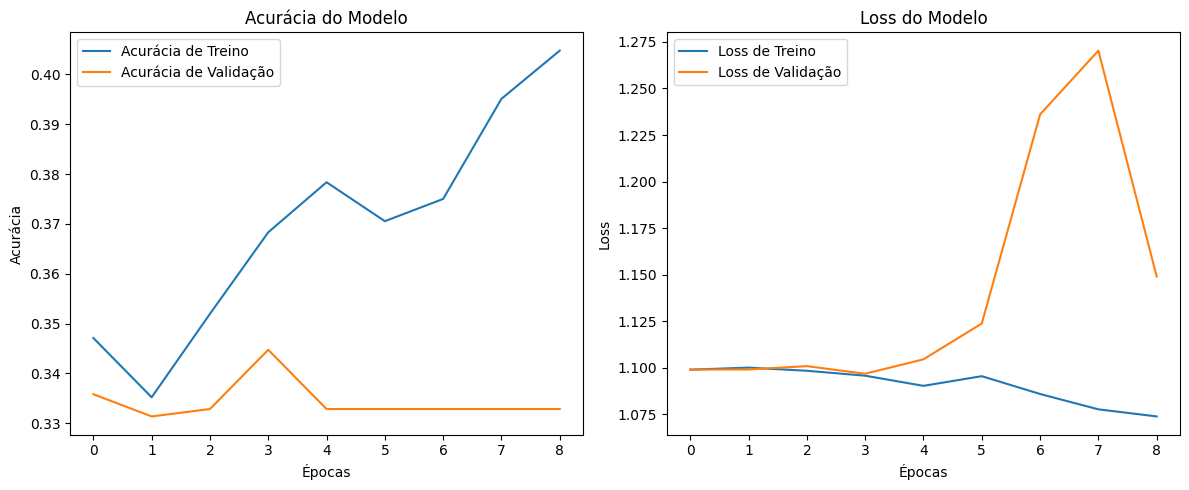

In [ ]:
#USANDO A AÇÃO NO MEIO DA STFT

import os
import time
import mne
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import random

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS
# ====================================================================
DATA_PATH = 'data/physionet_data/'
TARGET_RUNS = ['03', '07', '11']
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..']

L_FREQ, H_FREQ = 8, 30
FS = 160
JANELA_S = 4.0 # AGORA, ESTE É O TAMANHO FIXO E GARANTIDO DA NOSSA JANELA
WINDOW_SIZE = int(JANELA_S * FS) # 4.0 * 160 = 640 amostras

FRAME_LENGTH = 64
FRAME_STEP = 16
FFT_LENGTH = 128

NUM_SUBJECTS = 50
TEST_SIZE = 0.2
EPOCHS = 20
BATCH_SIZE = 16

# ====================================================================
# 2. FUNÇÕES AUXILIARES
# ====================================================================
# A função `create_model` permanece a mesma.
def create_model(input_shape, num_classes):
    # ... (código da função create_model sem alterações)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Reshape((-1, 64)),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# A função `process_multichannel_signal` foi substituída por uma mais simples
def generate_spectrogram_for_window(window_data, fs=FS, fft_length=FFT_LENGTH):
    """
    Gera um único tensor de espectrograma (freq, tempo, canal) para uma janela de dados já extraída.
    """
    num_channels = window_data.shape[0]
    channel_spectrograms = []
    for i in range(num_channels):
        stft = np.abs(tf.signal.stft(
            window_data[i],
            frame_length=FRAME_LENGTH,
            frame_step=FRAME_STEP,
            fft_length=fft_length
        ))
        channel_spectrograms.append(stft)
    
    # Empilha os espectrogramas no último eixo
    return np.stack(channel_spectrograms, axis=-1)

# ====================================================================
# 3. COLETA E PRÉ-PROCESSAMENTO DOS DADOS (LÓGICA REFEITA)
# ====================================================================
print("Iniciando coleta e pré-processamento de dados guiado por eventos...")
all_spectrograms = []
all_labels = []

# --- Cálculo dos Índices de Frequência para Recorte ---
freqs = np.fft.rfftfreq(n=FFT_LENGTH, d=1/FS)
freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]
print(f"Espectrogramas serão recortados para {len(freq_indices)} bins de frequência.")

# --- Loop principal para varrer todos os sujeitos e arquivos ---
files_processed = 0
for subject_num in range(1, NUM_SUBJECTS + 1):
    subject_id = f'S{subject_num:03d}'
    subject_path = os.path.join(DATA_PATH, subject_id)

    if not os.path.isdir(subject_path):
        continue

    for run_num in TARGET_RUNS:
        file_name = f'{subject_id}R{run_num}.edf'
        file_path = os.path.join(subject_path, file_name)

        if os.path.exists(file_path):
            try:
                print(f"Processando arquivo: {file_path}")
                files_processed += 1
                
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

                # >>> INÍCIO DA NOVA LÓGICA DE COLETA <<<
                # Itera sobre cada anotação (evento) no arquivo
                for ann in raw.annotations:
                    label = ann['description']
                    # Processamos apenas os eventos T0, T1, T2
                    if label in ['T0', 'T1', 'T2']:
                        # Encontra o centro do evento
                        event_center_s = ann['onset'] + (ann['duration'] / 2)
                        
                        # Define o início e o fim da nossa janela FIXA de 4.0s
                        window_start_s = event_center_s - (JANELA_S / 2)
                        window_end_s = event_center_s + (JANELA_S / 2)

                        # Garante que a janela não saia dos limites do arquivo
                        if window_start_s >= 0 and window_end_s <= raw.times[-1]:
                            # Converte tempo em segundos para índices de amostra
                            start_sample, stop_sample = raw.time_as_index([window_start_s, window_end_s])
                            
                            # Extrai exatamente o trecho de dados correspondente à janela
                            window_data = raw.get_data(picks=TARGET_CHANNELS, start=start_sample, stop=stop_sample)
                            
                            # Gera o espectrograma para esta janela
                            spectrogram = generate_spectrogram_for_window(window_data)
                            
                            # Recorta na dimensão da frequência
                            spectrogram_cropped = spectrogram[freq_indices, :, :]
                            
                            all_spectrograms.append(spectrogram_cropped)
                            all_labels.append(label)

            except Exception as e:
                print(f"Erro ao processar {file_path}: {e}")

# ====================================================================
# 4. BALANCEAMENTO DO DATASET (UNDERSAMPLING)
# ====================================================================
print("\nIniciando balanceamento do dataset...")

data_t0 = [spec for spec, label in zip(all_spectrograms, all_labels) if label == 'T0']
data_t1 = [spec for spec, label in zip(all_spectrograms, all_labels) if label == 'T1']
data_t2 = [spec for spec, label in zip(all_spectrograms, all_labels) if label == 'T2']

print(f"Contagem antes do balanceamento: T0={len(data_t0)}, T1={len(data_t1)}, T2={len(data_t2)}")

target_count = (len(data_t1) + len(data_t2)) // 2
target_count = min(target_count, len(data_t0)) 

print(f"Reduzindo amostras de T0 para aproximadamente {target_count}...")
random.shuffle(data_t0)
data_t0_balanced = data_t0[:target_count]

X_balanced = np.array(data_t0_balanced + data_t1 + data_t2)
y_str_balanced = np.array(['T0'] * len(data_t0_balanced) + ['T1'] * len(data_t1) + ['T2'] * len(data_t2))

print(f"Contagem após o balanceamento: T0={len(data_t0_balanced)}, T1={len(data_t1)}, T2={len(data_t2)}")

# ====================================================================
# 5. PREPARAÇÃO FINAL E DIVISÃO DO DATASET BALANCEADO
# ====================================================================
encoder = LabelEncoder()
y_balanced = encoder.fit_transform(y_str_balanced)

permutation = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[permutation]
y_balanced = y_balanced[permutation]

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=TEST_SIZE, random_state=42, stratify=y_balanced
)
print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")

# ====================================================================
# 6. CRIAÇÃO, TREINAMENTO E AVALIAÇÃO DO MODELO
# ====================================================================
if len(X_train) > 0:
    input_shape = X_train.shape[1:]
    num_classes = len(encoder.classes_)

    model = create_model(input_shape, num_classes)
    model.summary()

    print("\nIniciando o treinamento do modelo...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )
    
    # ... (Resto do código de avaliação e plotagem) ...
    print("\nTreinamento finalizado. Avaliando o modelo no conjunto de teste...")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nAcurácia no conjunto de teste: {accuracy*100:.2f}%")
    print(f"Loss no conjunto de teste: {loss:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Acurácia de Treino')
    plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
    plt.title('Acurácia do Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss de Treino')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.title('Loss do Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Nenhum dado foi gerado. Verifique os caminhos e parâmetros.")

In [14]:
import os
import time
import mne
import numpy as np
import tensorflow as tf  # Usado apenas para a função STFT
import matplotlib.pyplot as plt

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS
# ====================================================================
DATA_PATH = 'data/physionet_data/'
SAVE_IMAGES_PATH = 'espectrogramas_por_canal/' # Pasta principal para as imagens salvas
TARGET_RUNS = ['03', '07', '11']
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..']

L_FREQ, H_FREQ = 8, 30
FS = 160
JANELA_S = 4.0 # Tamanho fixo da janela de análise
WINDOW_SIZE = int(JANELA_S * FS) # 4.0 * 160 = 640 amostras

# Parâmetros da STFT
FRAME_LENGTH = 160 
FRAME_STEP = 16
FFT_LENGTH = 128

# Limitar o número de sujeitos para um teste mais rápido (opcional)
NUM_SUBJECTS = 1

# ====================================================================
# 2. FUNÇÃO AUXILIAR
# ====================================================================
def generate_single_channel_spectrogram(channel_data, fs=FS, fft_length=FFT_LENGTH):
    """
    Gera um único espectrograma 2D (freq, tempo) para uma janela de dados de um canal.
    """
    stft = np.abs(tf.signal.stft(
        channel_data,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=fft_length
    ))
    return stft

# ====================================================================
# 3. COLETA DE DADOS E GERAÇÃO DE IMAGENS
# ====================================================================
print("Iniciando geração do dataset de imagens...")
start_time_total = time.time()

# --- Cálculo dos Índices de Frequência para Recorte (feito uma vez) ---
freqs = np.fft.rfftfreq(n=FFT_LENGTH, d=1/FS)
freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]
freqs_recortadas = freqs[freq_indices]
print(f"Espectrogramas serão recortados para {len(freq_indices)} bins de frequência ({freqs_recortadas.min():.1f}-{freqs_recortadas.max():.1f} Hz).")

# --- Loop principal para varrer todos os sujeitos e arquivos ---
files_processed = 0
images_generated = 0
for subject_num in range(1, NUM_SUBJECTS + 1):
    subject_id = f'S{subject_num:03d}'
    subject_path = os.path.join(DATA_PATH, subject_id)

    if not os.path.isdir(subject_path):
        continue

    for run_num in TARGET_RUNS:
        file_name = f'{subject_id}R{run_num}.edf'
        file_path = os.path.join(subject_path, file_name)

        if os.path.exists(file_path):
            try:
                print(f"Processando arquivo: {file_path}")
                files_processed += 1
                
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

                # Itera sobre cada anotação (evento) no arquivo
                for ann_idx, ann in enumerate(raw.annotations):
                    label = ann['description']
                    
                    if label in ['T0', 'T1', 'T2']:
                        # Define a janela de 4s centrada no evento
                        event_center_s = ann['onset'] + (ann['duration'] / 2)
                        window_start_s = event_center_s - (JANELA_S / 2)
                        window_end_s = event_center_s + (JANELA_S / 2)

                        # Garante que a janela está dentro dos limites do arquivo
                        if window_start_s >= 0 and window_end_s <= raw.times[-1]:
                            start_sample, stop_sample = raw.time_as_index([window_start_s, window_end_s])
                            
                            # >>> INÍCIO DA LÓGICA POR CANAL <<<
                            # Itera sobre cada canal de interesse para este evento
                            for channel_name in TARGET_CHANNELS:
                                # Extrai os dados APENAS para o canal atual
                                window_data_single_channel = raw.get_data(picks=[channel_name], start=start_sample, stop=stop_sample)[0]
                                
                                # Gera o espectrograma para este canal
                                spectrogram = generate_single_channel_spectrogram(window_data_single_channel)
                                
                                # Recorta na dimensão da frequência
                                spectrogram_cropped = spectrogram[freq_indices, :]
                                
                                # --- Lógica de Salvamento da Imagem ---
                                # Remove os pontos do nome do canal para criar a pasta
                                channel_folder_name = channel_name.replace('.', '')
                                
                                # Cria a estrutura de pastas: Canal -> Classe
                                save_path_final = os.path.join(SAVE_IMAGES_PATH, channel_folder_name, label)
                                os.makedirs(save_path_final, exist_ok=True)
                                
                                # Nome descritivo para o arquivo
                                img_filename = f'{subject_id}_R{run_num}_evento_{ann_idx:03d}.png'
                                full_img_path = os.path.join(save_path_final, img_filename)

                                # Plotagem e salvamento
                                fig, ax = plt.subplots(figsize=(5, 4))
                                im = ax.imshow(spectrogram_cropped.T, aspect='auto', origin='lower', cmap='viridis', 
                                               extent=[0, spectrogram_cropped.shape[1], freqs_recortadas.min(), freqs_recortadas.max()])
                                fig.colorbar(im, ax=ax, label='Magnitude')
                                ax.set_title(f'{channel_name} | Classe: {label}')
                                ax.set_ylabel('Frequência (Hz)')
                                ax.set_xlabel('Tempo (frames)')
                                
                                plt.tight_layout()
                                plt.savefig(full_img_path)
                                plt.close(fig) # Fecha a figura para liberar memória
                                images_generated += 1
            except Exception as e:
                print(f"Erro ao processar {file_path}: {e}")

end_time_total = time.time()
print(f"\n\n{'*' * 50}")
print("GERAÇÃO DE IMAGENS CONCLUÍDA!")
print(f"Tempo total de execução: {end_time_total - start_time_total:.2f} segundos.")
print(f"Total de imagens geradas: {images_generated}")
print(f"Verifique a pasta '{SAVE_IMAGES_PATH}' para ver os resultados.")
print(f"{'*' * 50}")

Iniciando geração do dataset de imagens...
Espectrogramas serão recortados para 18 bins de frequência (8.8-30.0 Hz).
Processando arquivo: data/physionet_data/S001\S001R03.edf
Processando arquivo: data/physionet_data/S001\S001R07.edf
Processando arquivo: data/physionet_data/S001\S001R11.edf


**************************************************
GERAÇÃO DE IMAGENS CONCLUÍDA!
Tempo total de execução: 46.57 segundos.
Total de imagens geradas: 270
Verifique a pasta 'espectrogramas_por_canal/' para ver os resultados.
**************************************************


In [15]:
for ann_idx, ann in enumerate(raw.annotations):
    print(ann['description'], ann['onset'], ann['duration'])

T0 0.0 4.2
T1 4.2 4.1
T0 8.3 4.2
T2 12.5 4.1
T0 16.6 4.2
T2 20.8 4.1
T0 24.9 4.2
T1 29.1 4.1
T0 33.2 4.2
T2 37.4 4.1
T0 41.5 4.2
T1 45.7 4.1
T0 49.8 4.2
T1 54.0 4.1
T0 58.1 4.2
T2 62.3 4.1
T0 66.4 4.2
T2 70.6 4.1
T0 74.7 4.2
T1 78.9 4.1
T0 83.0 4.2
T1 87.2 4.1
T0 91.3 4.2
T2 95.5 4.1
T0 99.6 4.2
T2 103.8 4.1
T0 107.9 4.2
T1 112.1 4.1
T0 116.2 4.2
T2 120.4 4.1


In [16]:
import os
import time
import mne
import numpy as np
import tensorflow as tf  # Usado apenas para a função STFT
import matplotlib.pyplot as plt

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS
# ====================================================================
DATA_PATH = 'data/physionet_data/'
SAVE_IMAGES_PATH = 'espectrogramas_multicanal_por_classe/' # Nova pasta para as imagens salvas
TARGET_RUNS = ['03', '07', '11']
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..'] # A ordem aqui define a ordem nos plots

L_FREQ, H_FREQ = 8, 30
FS = 160
JANELA_S = 4.0 # Tamanho fixo da janela de análise
WINDOW_SIZE = int(JANELA_S * FS) # 4.0 * 160 = 640 amostras

# Parâmetros da STFT
FRAME_LENGTH = 64 
FRAME_STEP = 16
FFT_LENGTH = 128

# Limitar o número de sujeitos para um teste mais rápido (opcional)
NUM_SUBJECTS = 1

# ====================================================================
# 2. FUNÇÃO AUXILIAR
# ====================================================================
def generate_multichannel_spectrogram(multichannel_data, fs=FS, fft_length=FFT_LENGTH):
    """
    Gera um único tensor de espectrograma (freq, tempo, canal) para uma janela de dados já extraída.
    """
    num_channels = multichannel_data.shape[0]
    channel_spectrograms = []
    for i in range(num_channels):
        stft = np.abs(tf.signal.stft(
            multichannel_data[i],
            frame_length=FRAME_LENGTH,
            frame_step=FRAME_STEP,
            fft_length=fft_length
        ))
        channel_spectrograms.append(stft)
    
    # Empilha os espectrogramas no último eixo para criar o tensor (freq, tempo, canais)
    return np.stack(channel_spectrograms, axis=-1)

# ====================================================================
# 3. COLETA DE DADOS E GERAÇÃO DE IMAGENS
# ====================================================================
print("Iniciando geração de imagens multicanal por evento...")
start_time_total = time.time()

# --- Cálculo dos Índices de Frequência para Recorte (feito uma vez) ---
freqs = np.fft.rfftfreq(n=FFT_LENGTH, d=1/FS)
freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]
freqs_recortadas = freqs[freq_indices]
print(f"Espectrogramas serão recortados para {len(freq_indices)} bins de frequência ({freqs_recortadas.min():.1f}-{freqs_recortadas.max():.1f} Hz).")

# --- Loop principal para varrer todos os sujeitos e arquivos ---
files_processed = 0
images_generated = 0
for subject_num in range(1, NUM_SUBJECTS + 1):
    subject_id = f'S{subject_num:03d}'
    subject_path = os.path.join(DATA_PATH, subject_id)

    if not os.path.isdir(subject_path):
        continue

    for run_num in TARGET_RUNS:
        file_name = f'{subject_id}R{run_num}.edf'
        file_path = os.path.join(subject_path, file_name)

        if os.path.exists(file_path):
            try:
                print(f"Processando arquivo: {file_path}")
                files_processed += 1
                
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

                # Itera sobre cada anotação (evento) no arquivo
                for ann_idx, ann in enumerate(raw.annotations):
                    label = ann['description']
                    
                    if label in ['T0', 'T1', 'T2']:
                        # Define a janela de 4s centrada no evento
                        event_center_s = ann['onset'] + (ann['duration'] / 2)
                        window_start_s = event_center_s - (JANELA_S / 2)
                        window_end_s = event_center_s + (JANELA_S / 2)

                        # Garante que a janela está dentro dos limites do arquivo
                        if window_start_s >= 0 and window_end_s <= raw.times[-1]:
                            start_sample, stop_sample = raw.time_as_index([window_start_s, window_end_s])
                            
                            # Extrai os dados de TODOS os canais de interesse de uma vez
                            multichannel_window_data = raw.get_data(picks=TARGET_CHANNELS, start=start_sample, stop=stop_sample)
                            
                            # Gera o espectrograma 3D (freq, tempo, canal)
                            spectrogram_3d = generate_multichannel_spectrogram(multichannel_window_data)
                            
                            # Recorta na dimensão da frequência
                            spectrogram_3d_cropped = spectrogram_3d[freq_indices, :, :]
                            
                            # --- Lógica de Salvamento da Imagem Composta ---
                            # Cria a estrutura de pastas: Classe -> Imagem
                            save_path_final = os.path.join(SAVE_IMAGES_PATH, label)
                            os.makedirs(save_path_final, exist_ok=True)
                            
                            img_filename = f'{subject_id}_R{run_num}_evento_{ann_idx:03d}.png'
                            full_img_path = os.path.join(save_path_final, img_filename)

                            # --- Plotagem com Subplots ---
                            fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 linha, 3 colunas
                            fig.suptitle(f'Evento #{ann_idx} | Classe: {label} | Arquivo: {subject_id}-R{run_num}', fontsize=16)
                            
                            # Encontra o valor máximo de magnitude entre os 3 canais para a escala de cores ser a mesma
                            vmax = spectrogram_3d_cropped.max()

                            for i, channel_name in enumerate(TARGET_CHANNELS):
                                ax = axes[i]
                                # Extrai o espectrograma do canal 'i'
                                single_channel_spec = spectrogram_3d_cropped[:, :, i]
                                
                                im = ax.imshow(single_channel_spec.T, aspect='auto', origin='lower', cmap='viridis', 
                                               extent=[0, single_channel_spec.shape[1], freqs_recortadas.min(), freqs_recortadas.max()],
                                               vmin=0, vmax=vmax) # Usa a mesma escala de cor para todos
                                
                                ax.set_title(f'Canal: {channel_name}')
                                ax.set_ylabel('Frequência (Hz)')
                                ax.set_xlabel('Tempo (frames)')
                            
                            # Adiciona uma única barra de cor para a figura inteira
                            fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label='Magnitude')
                            plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Ajusta o layout para o título principal caber
                            
                            plt.savefig(full_img_path)
                            plt.close(fig) # Fecha a figura para liberar memória
                            images_generated += 1
            except Exception as e:
                print(f"Erro ao processar {file_path}: {e}")

end_time_total = time.time()
print(f"\n\n{'*' * 50}")
print("GERAÇÃO DE IMAGENS CONCLUÍDA!")
print(f"Tempo total de execução: {end_time_total - start_time_total:.2f} segundos.")
print(f"Total de imagens compostas geradas: {images_generated}")
print(f"Verifique a pasta '{SAVE_IMAGES_PATH}' para ver os resultados.")
print(f"{'*' * 50}")

Iniciando geração de imagens multicanal por evento...
Espectrogramas serão recortados para 18 bins de frequência (8.8-30.0 Hz).
Processando arquivo: data/physionet_data/S001\S001R03.edf


C:\Users\luize\AppData\Local\Temp\ipykernel_2980\3302124765.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Ajusta o layout para o título principal caber


Processando arquivo: data/physionet_data/S001\S001R07.edf
Processando arquivo: data/physionet_data/S001\S001R11.edf


**************************************************
GERAÇÃO DE IMAGENS CONCLUÍDA!
Tempo total de execução: 38.32 segundos.
Total de imagens compostas geradas: 90
Verifique a pasta 'espectrogramas_multicanal_por_classe/' para ver os resultados.
**************************************************


In [17]:
import os
import time
import mne
import numpy as np
import tensorflow as tf  # Usado apenas para a função STFT
import matplotlib.pyplot as plt

# ====================================================================
# 1. CONFIGURAÇÕES E PARÂMETROS
# ====================================================================
DATA_PATH = 'data/physionet_data/'
SAVE_IMAGES_PATH = 'espectrogramas_rgb_por_classe/' # Nova pasta para as imagens RGB
TARGET_RUNS = ['03', '07', '11']
# A ordem aqui é MUITO importante: ela define o mapeamento R, G, B
TARGET_CHANNELS = ['C3..', 'C4..', 'Cz..'] # R=C3, G=C4, B=Cz

L_FREQ, H_FREQ = 8, 30
FS = 160
JANELA_S = 4.0
WINDOW_SIZE = int(JANELA_S * FS)

FRAME_LENGTH = 64 
FRAME_STEP = 16
FFT_LENGTH = 128

NUM_SUBJECTS = 1

# ====================================================================
# 2. FUNÇÃO AUXILIAR
# ====================================================================
def generate_multichannel_spectrogram(multichannel_data, fs=FS, fft_length=FFT_LENGTH):
    """
    Gera um único tensor de espectrograma (freq, tempo, canal) para uma janela de dados já extraída.
    """
    num_channels = multichannel_data.shape[0]
    channel_spectrograms = []
    for i in range(num_channels):
        stft = np.abs(tf.signal.stft(
            multichannel_data[i],
            frame_length=FRAME_LENGTH,
            frame_step=FRAME_STEP,
            fft_length=fft_length
        ))
        channel_spectrograms.append(stft)
    return np.stack(channel_spectrograms, axis=-1)

# ====================================================================
# 3. COLETA DE DADOS E GERAÇÃO DE IMAGENS RGB
# ====================================================================
print("Iniciando geração do dataset de imagens RGB...")
start_time_total = time.time()

freqs = np.fft.rfftfreq(n=FFT_LENGTH, d=1/FS)
freq_indices = np.where((freqs >= L_FREQ) & (freqs <= H_FREQ))[0]
freqs_recortadas = freqs[freq_indices]
print(f"Espectrogramas serão recortados para {len(freq_indices)} bins de frequência.")

files_processed = 0
images_generated = 0
for subject_num in range(1, NUM_SUBJECTS + 1):
    subject_id = f'S{subject_num:03d}'
    subject_path = os.path.join(DATA_PATH, subject_id)

    if not os.path.isdir(subject_path):
        continue

    for run_num in TARGET_RUNS:
        file_name = f'{subject_id}R{run_num}.edf'
        file_path = os.path.join(subject_path, file_name)

        if os.path.exists(file_path):
            try:
                print(f"Processando arquivo: {file_path}")
                files_processed += 1
                
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
                raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, verbose=False)

                for ann_idx, ann in enumerate(raw.annotations):
                    label = ann['description']
                    if label in ['T0', 'T1', 'T2']:
                        event_center_s = ann['onset'] + (ann['duration'] / 2)
                        window_start_s = event_center_s - (JANELA_S / 2)
                        window_end_s = event_center_s + (JANELA_S / 2)

                        if window_start_s >= 0 and window_end_s <= raw.times[-1]:
                            start_sample, stop_sample = raw.time_as_index([window_start_s, window_end_s])
                            multichannel_window_data = raw.get_data(picks=TARGET_CHANNELS, start=start_sample, stop=stop_sample)
                            
                            spectrogram_3d = generate_multichannel_spectrogram(multichannel_window_data)
                            spectrogram_3d_cropped = spectrogram_3d[freq_indices, :, :]
                            
                            # --- LÓGICA DE NORMALIZAÇÃO E CRIAÇÃO DA IMAGEM RGB ---
                            
                            # Encontra o valor máximo global para normalização
                            vmax = spectrogram_3d_cropped.max()
                            if vmax == 0: continue # Pula se o espectrograma for todo preto
                            
                            # Normaliza os dados para o intervalo [0, 1]
                            rgb_spec = spectrogram_3d_cropped / vmax
                            
                            # --- Lógica de Salvamento da Imagem RGB ---
                            save_path_final = os.path.join(SAVE_IMAGES_PATH, label)
                            os.makedirs(save_path_final, exist_ok=True)
                            
                            img_filename = f'{subject_id}_R{run_num}_evento_{ann_idx:03d}.png'
                            full_img_path = os.path.join(save_path_final, img_filename)

                            # --- Plotagem e salvamento ---
                            fig, ax = plt.subplots(figsize=(5, 4))
                            
                            # imshow pode plotar um array (altura, largura, 3) diretamente como uma imagem RGB
                            ax.imshow(rgb_spec, aspect='auto', origin='lower', 
                                      extent=[0, rgb_spec.shape[1], freqs_recortadas.min(), freqs_recortadas.max()])
                            
                            ax.set_title(f'Classe: {label} | R={TARGET_CHANNELS[0]}, G={TARGET_CHANNELS[1]}, B={TARGET_CHANNELS[2]}')
                            ax.set_ylabel('Frequência (Hz)')
                            ax.set_xlabel('Tempo (frames)')
                            
                            plt.tight_layout()
                            plt.savefig(full_img_path)
                            plt.close(fig)
                            images_generated += 1
            except Exception as e:
                print(f"Erro ao processar {file_path}: {e}")

end_time_total = time.time()
print(f"\n\n{'*' * 50}")
print("GERAÇÃO DE IMAGENS RGB CONCLUÍDA!")
print(f"Tempo total de execução: {end_time_total - start_time_total:.2f} segundos.")
print(f"Total de imagens geradas: {images_generated}")
print(f"Verifique a pasta '{SAVE_IMAGES_PATH}' para ver os resultados.")
print(f"{'*' * 50}")

Iniciando geração do dataset de imagens RGB...
Espectrogramas serão recortados para 18 bins de frequência.
Processando arquivo: data/physionet_data/S001\S001R03.edf
Processando arquivo: data/physionet_data/S001\S001R07.edf
Processando arquivo: data/physionet_data/S001\S001R11.edf


**************************************************
GERAÇÃO DE IMAGENS RGB CONCLUÍDA!
Tempo total de execução: 11.97 segundos.
Total de imagens geradas: 90
Verifique a pasta 'espectrogramas_rgb_por_classe/' para ver os resultados.
**************************************************
